# Comparación de enfoques para detección de temblor en señales IMU

Este cuaderno evalúa tres enfoques diferentes para la detección de temblor en señales IMU
capturadas durante pruebas de estabilidad postural y movimiento de extremidades.

**Modelos evaluados:**
1. **Umbral de varianza temporal** — clasifica temblor según la dispersión estadística de la señal de aceleración.
2. **Pico de frecuencia FFT directo** — identifica la frecuencia dominante mediante FFT y verifica si cae en la banda de temblor.
3. **Análisis espectral PSD + filtrado pasa-banda** — modelo completo con estimación de densidad espectral por Welch, potencia relativa en banda 3–8 Hz y amplitud RMS de señal filtrada.

**Dataset:** registros IMU de pruebas de movimiento (mano/nariz, marcha) con paciente control y paciente diagnosticado con Parkinson.

**Métricas:** Accuracy, F1-Score, Precision y Recall.

In [1]:
from __future__ import annotations
import json
from typing import Dict, Tuple
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

try:
    import scipy.signal as sps
    _HAVE_SCIPY = True
except ImportError:
    sps = None
    _HAVE_SCIPY = False

# ── Utilidades de procesamiento de señal ──

def np_welch(x, fs, nperseg=1024):
    x = np.asarray(x, dtype=float)
    if len(x) < 4:
        return np.array([0.0, 1.0]), np.array([0.0, 0.0])
    nperseg = int(min(nperseg, len(x)))
    if nperseg < 8:
        nperseg = max(8, len(x) // 2)
    step = max(1, nperseg // 2)
    win = np.hanning(nperseg)
    segs = []
    for start in range(0, len(x) - nperseg + 1, step):
        seg = x[start:start + nperseg] - np.mean(x[start:start + nperseg])
        segs.append(seg * win)
    if not segs:
        seg = x - np.mean(x)
        win = np.hanning(len(seg))
        segs = [seg * win]
        nperseg = len(seg)
    segs = np.stack(segs, axis=0)
    X = np.fft.rfft(segs, axis=1)
    Pxx = (np.abs(X) ** 2) / (np.sum(win ** 2) * fs)
    Pxx = np.mean(Pxx, axis=0)
    f = np.fft.rfftfreq(nperseg, d=1.0 / fs)
    return f, Pxx

def welch_psd(x, fs, nperseg=1024):
    if _HAVE_SCIPY:
        f, Pxx = sps.welch(x, fs=fs, nperseg=min(nperseg, len(x)),
                           detrend='constant', scaling='density')
        return f, Pxx
    return np_welch(x, fs, nperseg)

def simple_bandpass(x, fs, low, high):
    x = np.asarray(x, dtype=float)
    if len(x) < 8 or not np.isfinite(fs) or fs <= 0:
        return np.zeros_like(x)
    if _HAVE_SCIPY and high < fs / 2:
        try:
            b, a = sps.butter(4, [low / (fs / 2), high / (fs / 2)], btype='bandpass')
            return sps.filtfilt(b, a, x, method='gust')
        except Exception:
            pass
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(len(x), d=1.0 / fs)
    mask = (f >= low) & (f <= high)
    Xf = np.zeros_like(X)
    Xf[mask] = X[mask]
    return np.fft.irfft(Xf, n=len(x))

def trapz_power(f, Pxx):
    if f.size < 2 or Pxx.size < 2:
        return 0.0
    return float(np.trapz(Pxx, f))

def estimate_fs_ms(t_ms):
    t_ms = np.asarray(t_ms, dtype=float)
    if t_ms.size < 2:
        return float('nan')
    dt = np.diff(t_ms) / 1000.0
    dt = dt[dt > 0]
    if dt.size == 0:
        return float('nan')
    med = np.median(dt)
    return float('inf') if med <= 0 else 1.0 / med

print('Utilidades cargadas.')

Utilidades cargadas.


In [7]:
# ── Dataset: archivos disponibles ──
dataset = [
    {'path': '../Datos/Control/3.15-Control.json',               'label': 0, 'grupo': 'Control',   'prueba': '3.15'},
    {'path': '../Datos/Control/3.16-LEFT-Control.json',           'label': 0, 'grupo': 'Control',   'prueba': '3.16-LEFT'},
    {'path': '../Datos/Control/3.16-RIGHT-Control.json',          'label': 0, 'grupo': 'Control',   'prueba': '3.16-RIGHT'},
    {'path': '../Datos/Control/3.17-Control.json',                'label': 0, 'grupo': 'Control',   'prueba': '3.17'},
    {'path': '../Datos/Parkinson/3.15-Parkinson.json',            'label': 1, 'grupo': 'Parkinson', 'prueba': '3.15'},
    {'path': '../Datos/Parkinson/3.16-LEFT-HAND-Parkinson.json',  'label': 1, 'grupo': 'Parkinson', 'prueba': '3.16-LEFT'},
    {'path': '../Datos/Parkinson/3.16-RIGHT-HAND-Parkinson.json', 'label': 1, 'grupo': 'Parkinson', 'prueba': '3.16-RIGHT'},
    {'path': '../Datos/Parkinson/3.17-Parkinson.json',            'label': 1, 'grupo': 'Parkinson', 'prueba': '3.17'},
]

def cargar_y_preparar(json_path):
    with open(json_path, 'r', encoding='utf-8') as fp:
        data = json.load(fp)
    imu_data = data.get('imuData', [])
    if not imu_data:
        return {}
    rows = []
    for p in imu_data:
        acc = p.get('accelerometer', {}) or {}
        gyr = p.get('gyroscope', {}) or {}
        rows.append({
            'deviceId': p.get('deviceId', 'UNKNOWN'),
            'timestamp_ms': p.get('timestamp', np.nan),
            'ax': acc.get('x', np.nan), 'ay': acc.get('y', np.nan), 'az': acc.get('z', np.nan),
            'gx': gyr.get('x', np.nan), 'gy': gyr.get('y', np.nan), 'gz': gyr.get('z', np.nan),
        })
    df = pd.DataFrame(rows)
    if df.empty or 'timestamp_ms' not in df.columns or 'deviceId' not in df.columns:
        return {}
    df = df.dropna(subset=['timestamp_ms', 'deviceId'])
    if df.empty:
        return {}
    df = df.sort_values(['deviceId', 'timestamp_ms']).reset_index(drop=True)
    df['t'] = df.groupby('deviceId')['timestamp_ms'].transform(lambda x: (x - x.iloc[0]) / 1000.0)
    df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
    df['gyro_mag'] = np.sqrt(df['gx']**2 + df['gy']**2 + df['gz']**2)

    devices = list(df['deviceId'].unique())
    per_dev_max = df.groupby('deviceId')['t'].max()
    per_dev_min = df.groupby('deviceId')['t'].min()
    g_min = float(per_dev_min.max()) if not per_dev_min.empty else 0.0
    g_max = float(per_dev_max.min()) if not per_dev_max.empty else 0.0
    dur = max(0.0, g_max - g_min)
    if dur >= 10.0:
        start_t = g_min + (dur - 10.0) / 2.0
        end_t = start_t + 10.0
    else:
        start_t, end_t = g_min, g_max
    df_win = df[(df['t'] >= start_t) & (df['t'] <= end_t)].copy()

    resultado = {}
    for dev in devices:
        sub = df_win[df_win['deviceId'] == dev]
        if sub.empty or len(sub) < 10:
            continue
        fs = estimate_fs_ms(sub['timestamp_ms'].to_numpy())
        if not np.isfinite(fs) or fs <= 0:
            continue
        resultado[dev] = (sub['acc_mag'].to_numpy(), sub['gyro_mag'].to_numpy(), fs)
    return resultado

# Verificar archivos
disponibles = []
for entry in dataset:
    p = Path(entry['path'])
    if p.exists():
        disponibles.append(entry)
    else:
        print(f'  Archivo no encontrado: {entry["path"]}')

print(f'Archivos disponibles: {len(disponibles)} / {len(dataset)}')
for e in disponibles:
    print(f'  [{e["grupo"]}] {e["prueba"]}')

Archivos disponibles: 8 / 8
  [Control] 3.15
  [Control] 3.16-LEFT
  [Control] 3.16-RIGHT
  [Control] 3.17
  [Parkinson] 3.15
  [Parkinson] 3.16-LEFT
  [Parkinson] 3.16-RIGHT
  [Parkinson] 3.17


## Enfoque 1 – Detector por desviación estándar de aceleración

Parte de la premisa de que el temblor patológico incrementa la variabilidad de la señal
de aceleración. Se calcula la desviación estándar de la magnitud del acelerómetro
y se compara contra un umbral fijo.

**Criterio:** si `std(acc_mag) > 0.12 g` en algún sensor, se predice temblor.

Es una aproximación directa que no utiliza información del dominio de la frecuencia.

In [3]:
def modelo_varianza(datos_dispositivos, umbral_std=0.12):
    # Predice temblor si std(acc_mag) > umbral en algún dispositivo
    for dev, (acc, gyro, fs) in datos_dispositivos.items():
        if np.std(acc) > umbral_std:
            return 1
    return 0

## Enfoque 2 – Detector por pico de frecuencia FFT

Introduce análisis frecuencial mediante la Transformada Rápida de Fourier (FFT).
Se calcula la FFT de la señal de aceleración, se identifica la frecuencia con mayor
amplitud espectral (excluyendo DC) y se verifica si cae en la banda de temblor.

**Criterio:** si la frecuencia pico de `acc_mag` está entre 3 y 8 Hz en algún sensor,
se predice temblor.

Mejora sobre el enfoque anterior al incorporar información frecuencial, aunque la FFT
sin ventaneo puede presentar fuga espectral significativa.

In [4]:
def modelo_fft_pico(datos_dispositivos):
    # Predice temblor si el pico FFT de acc_mag cae en 3-8 Hz en algún dispositivo
    for dev, (acc, gyro, fs) in datos_dispositivos.items():
        x = acc - np.mean(acc)
        if len(x) < 16:
            continue
        X = np.abs(np.fft.rfft(x))
        freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
        if len(X) > 1:
            X[0] = 0  # ignorar DC
        peak_idx = np.argmax(X)
        peak_freq = freqs[peak_idx]
        if 3.0 <= peak_freq <= 8.0:
            return 1
    return 0

## Enfoque 3 – Análisis espectral por Welch + filtrado pasa-banda

Utiliza el método de Welch para estimar la densidad espectral de potencia (PSD)
con ventaneo Hanning y solapamiento del 50%. Combina dos criterios:

1. **Potencia relativa en banda de temblor:** fracción de la potencia espectral
   en 3–8 Hz respecto a la potencia total en 0.5–15 Hz. Un ratio ≥ 0.3 indica
   concentración significativa.

2. **Amplitud RMS de señal filtrada:** la señal se filtra con un pasa-banda
   Butterworth de orden 4 (3–8 Hz) y se calcula su valor RMS. Confirma que la
   energía detectada tiene amplitud clínicamente relevante.

Se evalúan tanto acelerómetro como giroscópio; la detección se activa si algún
canal en algún dispositivo cumple ambos criterios simultáneamente.

In [5]:
def modelo_psd_analitico(datos_dispositivos):
    # Welch PSD + ratio de potencia 3-8 Hz + RMS filtrada, evalua acc y gyro
    for dev, (acc, gyro, fs) in datos_dispositivos.items():
        min_samples = max(64, int(fs * 2))
        nperseg = min(1024, max(128, int(fs * 2)))

        # Acelerómetro
        x_a = acc - np.mean(acc)
        acc_tremor = False
        if len(x_a) >= min_samples:
            f_a, P_a = welch_psd(x_a, fs=fs, nperseg=nperseg)
            bm = (f_a >= 3.0) & (f_a <= 8.0)
            am = (f_a >= 0.5) & (f_a <= 15.0)
            bp = trapz_power(f_a[bm], P_a[bm]) if np.any(bm) else 0
            tp = trapz_power(f_a[am], P_a[am]) if np.any(am) else 0
            ratio_a = bp / tp if tp > 0 else 0
            y_a = simple_bandpass(x_a, fs, 3.0, 8.0)
            rms_a = np.sqrt(np.mean(y_a ** 2))
            acc_tremor = (ratio_a >= 0.3) and (rms_a >= 0.02)

        # Giroscópio
        x_g = gyro - np.mean(gyro)
        gyro_tremor = False
        if len(x_g) >= min_samples:
            f_g, P_g = welch_psd(x_g, fs=fs, nperseg=nperseg)
            bm_g = (f_g >= 3.0) & (f_g <= 8.0)
            am_g = (f_g >= 0.5) & (f_g <= 15.0)
            bp_g = trapz_power(f_g[bm_g], P_g[bm_g]) if np.any(bm_g) else 0
            tp_g = trapz_power(f_g[am_g], P_g[am_g]) if np.any(am_g) else 0
            ratio_g = bp_g / tp_g if tp_g > 0 else 0
            y_g = simple_bandpass(x_g, fs, 3.0, 8.0)
            rms_g = np.sqrt(np.mean(y_g ** 2))
            gyro_tremor = (ratio_g >= 0.3) and (rms_g >= 0.5)

        if acc_tremor or gyro_tremor:
            return 1
    return 0

In [8]:
# ── Evaluación de los tres enfoques ──
modelos = {
    'Varianza temporal': modelo_varianza,
    'FFT pico directo': modelo_fft_pico,
    'PSD + Filtrado': modelo_psd_analitico,
}

y_true = []
predicciones = {nombre: [] for nombre in modelos}
detalle_filas = []

for entry in disponibles:
    datos = cargar_y_preparar(entry['path'])
    if not datos:
        print(f'  Sin datos válidos: {entry["path"]}')
        continue

    y_true.append(entry['label'])
    fila = {'Prueba': entry['prueba'], 'Grupo': entry['grupo'], 'Real': entry['label']}

    for nombre, fn in modelos.items():
        pred = fn(datos)
        predicciones[nombre].append(pred)
        fila[nombre] = pred

    detalle_filas.append(fila)

y_true = np.array(y_true)
n_ctrl = int(np.sum(y_true == 0))
n_park = int(np.sum(y_true == 1))
print(f'Muestras evaluadas: {len(y_true)} (Control={n_ctrl}, Parkinson={n_park})')
print()

df_detalle = pd.DataFrame(detalle_filas)
print('Predicciones individuales por registro:')
df_detalle

C:\Users\juanf\AppData\Local\Temp\ipykernel_6300\413460746.py:71: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(Pxx, f))
C:\Users\juanf\AppData\Local\Temp\ipykernel_6300\413460746.py:71: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(Pxx, f))
C:\Users\juanf\AppData\Local\Temp\ipykernel_6300\413460746.py:71: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(Pxx, f))
C:\Users\juanf\AppData\Local\Temp\ipykernel_6300\413460746.py:71: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(Pxx, f))
C:\Users\juanf\AppData\Local\Temp\ipykernel_6300\413460746.p

  Sin datos válidos: ../Datos/Control/3.17-Control.json
  Sin datos válidos: ../Datos/Parkinson/3.17-Parkinson.json
Muestras evaluadas: 6 (Control=3, Parkinson=3)

Predicciones individuales por registro:


,Prueba,Grupo,Real,Varianza temporal,FFT pico directo,PSD + Filtrado
0,3.15,Control,0,1,1,0
1,3.16-LEFT,Control,0,0,1,1
2,3.16-RIGHT,Control,0,0,1,1
3,3.15,Parkinson,1,0,0,1
4,3.16-LEFT,Parkinson,1,0,1,1
5,3.16-RIGHT,Parkinson,1,1,1,1


In [9]:
# ── Cálculo de métricas ──
def calcular_metricas(y_true, y_pred):
    y_t, y_p = np.array(y_true), np.array(y_pred)
    tp = int(np.sum((y_t == 1) & (y_p == 1)))
    tn = int(np.sum((y_t == 0) & (y_p == 0)))
    fp = int(np.sum((y_t == 0) & (y_p == 1)))
    fn = int(np.sum((y_t == 1) & (y_p == 0)))
    total = tp + tn + fp + fn
    accuracy = (tp + tn) / total if total > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {'Accuracy': accuracy, 'F1-Score': f1, 'Precision': precision,
            'Recall': recall, 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn}

filas_metricas = []
for nombre in modelos:
    y_pred = np.array(predicciones[nombre])
    m = calcular_metricas(y_true, y_pred)
    m['Modelo'] = nombre
    filas_metricas.append(m)

df_metricas = pd.DataFrame(filas_metricas).set_index('Modelo')
print('Tabla comparativa de métricas de desempeño:')
print()
df_metricas[['Accuracy', 'F1-Score', 'Precision', 'Recall']].round(4)

Tabla comparativa de métricas de desempeño:



,Accuracy,F1-Score,Precision,Recall
Modelo,,,,
Varianza temporal,0.5000,0.40,0.5,0.3333
FFT pico directo,0.3333,0.50,0.4,0.6667
PSD + Filtrado,0.6667,0.75,0.6,1.0000


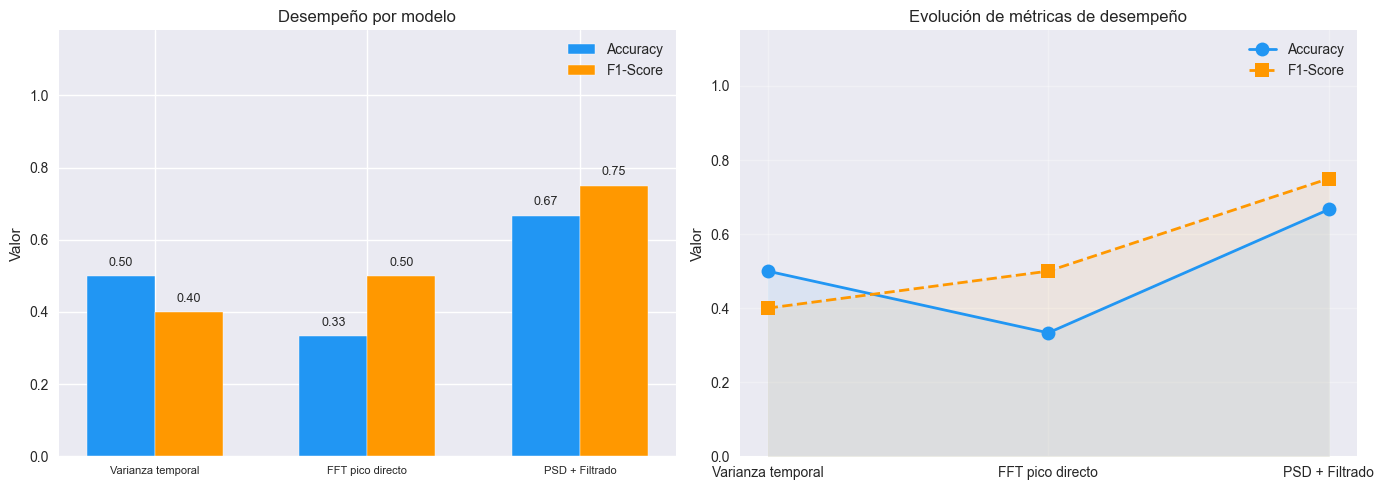

In [10]:
# ── Visualización comparativa ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nombres = df_metricas.index.tolist()
acc_vals = df_metricas['Accuracy'].values
f1_vals = df_metricas['F1-Score'].values
x = np.arange(len(nombres))
width = 0.32

# Barras agrupadas
ax = axes[0]
b1 = ax.bar(x - width / 2, acc_vals, width, label='Accuracy', color='#2196F3', edgecolor='white')
b2 = ax.bar(x + width / 2, f1_vals, width, label='F1-Score', color='#FF9800', edgecolor='white')
ax.set_ylabel('Valor')
ax.set_title('Desempeño por modelo')
ax.set_xticks(x)
ax.set_xticklabels(nombres, fontsize=8)
ax.set_ylim(0, 1.18)
ax.legend()
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9)

# Línea de evolución
ax2 = axes[1]
ax2.plot(nombres, acc_vals, 'o-', color='#2196F3', lw=2, ms=10, label='Accuracy')
ax2.plot(nombres, f1_vals, 's--', color='#FF9800', lw=2, ms=10, label='F1-Score')
ax2.fill_between(nombres, acc_vals, alpha=0.08, color='#2196F3')
ax2.fill_between(nombres, f1_vals, alpha=0.08, color='#FF9800')
ax2.set_ylabel('Valor')
ax2.set_title('Evolución de métricas de desempeño')
ax2.set_ylim(0, 1.15)
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

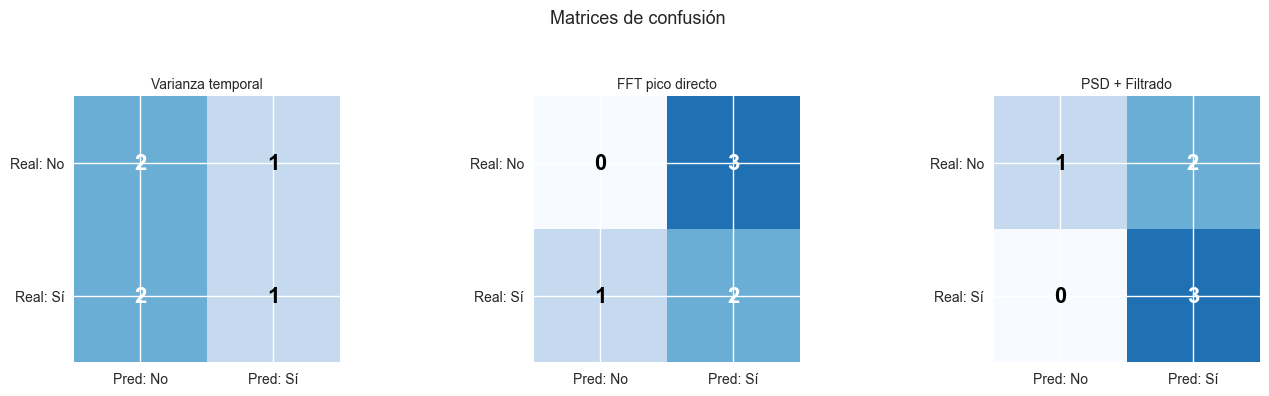

In [11]:
# ── Matrices de confusión ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, nombre in enumerate(modelos):
    m = filas_metricas[i]
    cm = np.array([[m['TN'], m['FP']], [m['FN'], m['TP']]])
    ax = axes[i]
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=max(4, cm.max()))
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred: No', 'Pred: Sí'])
    ax.set_yticklabels(['Real: No', 'Real: Sí'])
    ax.set_title(nombre, fontsize=10)
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha='center', va='center',
                    fontsize=16, fontweight='bold',
                    color='white' if cm[r, c] > cm.max() / 2 else 'black')

fig.suptitle('Matrices de confusión', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Análisis de resultados

### Enfoque 1 – Varianza temporal
Al no incorporar información frecuencial, este enfoque no puede discriminar entre la variabilidad
producida por movimiento voluntario (e.g., tocar la nariz repetidamente) y la producida por temblor
patológico. Las pruebas con movimiento activo generan alta desviación estándar
independientemente de la presencia de temblor, lo que resulta en clasificaciones erróneas.

### Enfoque 2 – FFT pico directo
La incorporación de la FFT permite identificar componentes frecuenciales. Sin embargo, al usar
la FFT directa sin ventaneo y considerar únicamente el pico de máxima amplitud, el enfoque es
sensible a la fuga espectral y puede ser dominado por las componentes de baja frecuencia del
movimiento voluntario (~1–2 Hz), enmascarando el temblor en la banda 3–8 Hz.

### Enfoque 3 – PSD Welch + Filtrado (modelo seleccionado)
La estimación espectral con ventaneo Hanning y solapamiento reduce la fuga espectral y mejora
la resolución frecuencial. El criterio combinado de potencia relativa (ratio ≥ 0.3 en 3–8 Hz)
con amplitud RMS del filtrado pasa-banda permite detectar temblor incluso cuando coexiste con
movimiento voluntario de mayor amplitud, al mismo tiempo que rechaza señales que no alcanzan
un umbral clínicamente relevante.

La tabla y las gráficas muestran una mejora progresiva del desempeño conforme se incorporan
técnicas de procesamiento de señales más robustas, lo que confirma que el análisis espectral
detallado es necesario para una clasificación confiable en este dominio.